In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("googleplaystore.csv")
print(df)

                                                     App             Category  \
0         Photo Editor & Candy Camera & Grid & ScrapBook       ART_AND_DESIGN   
1                                    Coloring book moana       ART_AND_DESIGN   
2      U Launcher Lite – FREE Live Cool Themes, Hide ...       ART_AND_DESIGN   
3                                  Sketch - Draw & Paint       ART_AND_DESIGN   
4                  Pixel Draw - Number Art Coloring Book       ART_AND_DESIGN   
...                                                  ...                  ...   
10836                                   Sya9a Maroc - FR               FAMILY   
10837                   Fr. Mike Schmitz Audio Teachings               FAMILY   
10838                             Parkinson Exercices FR              MEDICAL   
10839                      The SCP Foundation DB fr nn5n  BOOKS_AND_REFERENCE   
10840      iHoroscope - 2018 Daily Horoscope & Astrology            LIFESTYLE   

       Rating Reviews      

In [2]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB


In [4]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10836    False
10837    False
10838    False
10839    False
10840    False
Length: 10841, dtype: bool

In [5]:
df.duplicated().sum()

np.int64(483)

In [6]:
df.isnull()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,False,False,False,False,False,False,False,False,False,False,False,False,False
10837,False,False,False,False,False,False,False,False,False,False,False,False,False
10838,False,False,True,False,False,False,False,False,False,False,False,False,False
10839,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df=df.dropna(subset=['Rating'])

In [9]:
df=df.dropna(subset=['Type'])

In [10]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    1
Genres            0
Last Updated      0
Current Ver       4
Android Ver       3
dtype: int64

In [11]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [12]:
df['Category'].unique()

<ArrowStringArray>
[     'ART_AND_DESIGN',   'AUTO_AND_VEHICLES',              'BEAUTY',
 'BOOKS_AND_REFERENCE',            'BUSINESS',              'COMICS',
       'COMMUNICATION',              'DATING',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS',             'FINANCE',
      'FOOD_AND_DRINK',  'HEALTH_AND_FITNESS',      'HOUSE_AND_HOME',
  'LIBRARIES_AND_DEMO',           'LIFESTYLE',                'GAME',
              'FAMILY',             'MEDICAL',              'SOCIAL',
            'SHOPPING',         'PHOTOGRAPHY',              'SPORTS',
    'TRAVEL_AND_LOCAL',               'TOOLS',     'PERSONALIZATION',
        'PRODUCTIVITY',           'PARENTING',             'WEATHER',
       'VIDEO_PLAYERS',  'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
                 '1.9']
Length: 34, dtype: str

In [13]:
category_rating=df.groupby('Category')['Rating'].sum().sort_values(ascending=False).reset_index()
print(category_rating)

               Category  Rating
0                FAMILY  7323.9
1                  GAME  4702.1
2                 TOOLS  2970.8
3          PRODUCTIVITY  1478.2
4               MEDICAL  1466.2
5         COMMUNICATION  1364.0
6       PERSONALIZATION  1361.5
7                SPORTS  1347.3
8               FINANCE  1334.6
9           PHOTOGRAPHY  1328.9
10            LIFESTYLE  1285.8
11   HEALTH_AND_FITNESS  1270.3
12             BUSINESS  1248.8
13               SOCIAL  1102.2
14             SHOPPING  1013.8
15   NEWS_AND_MAGAZINES   962.8
16     TRAVEL_AND_LOCAL   928.7
17               DATING   774.3
18  BOOKS_AND_REFERENCE   773.6
19            EDUCATION   680.3
20        VIDEO_PLAYERS   650.2
21        ENTERTAINMENT   614.8
22  MAPS_AND_NAVIGATION   502.4
23       FOOD_AND_DRINK   454.2
24       HOUSE_AND_HOME   319.0
25              WEATHER   318.3
26    AUTO_AND_VEHICLES   305.9
27   LIBRARIES_AND_DEMO   271.6
28       ART_AND_DESIGN   270.2
29               COMICS   241.0
30      

<Axes: xlabel='Category', ylabel='Rating'>

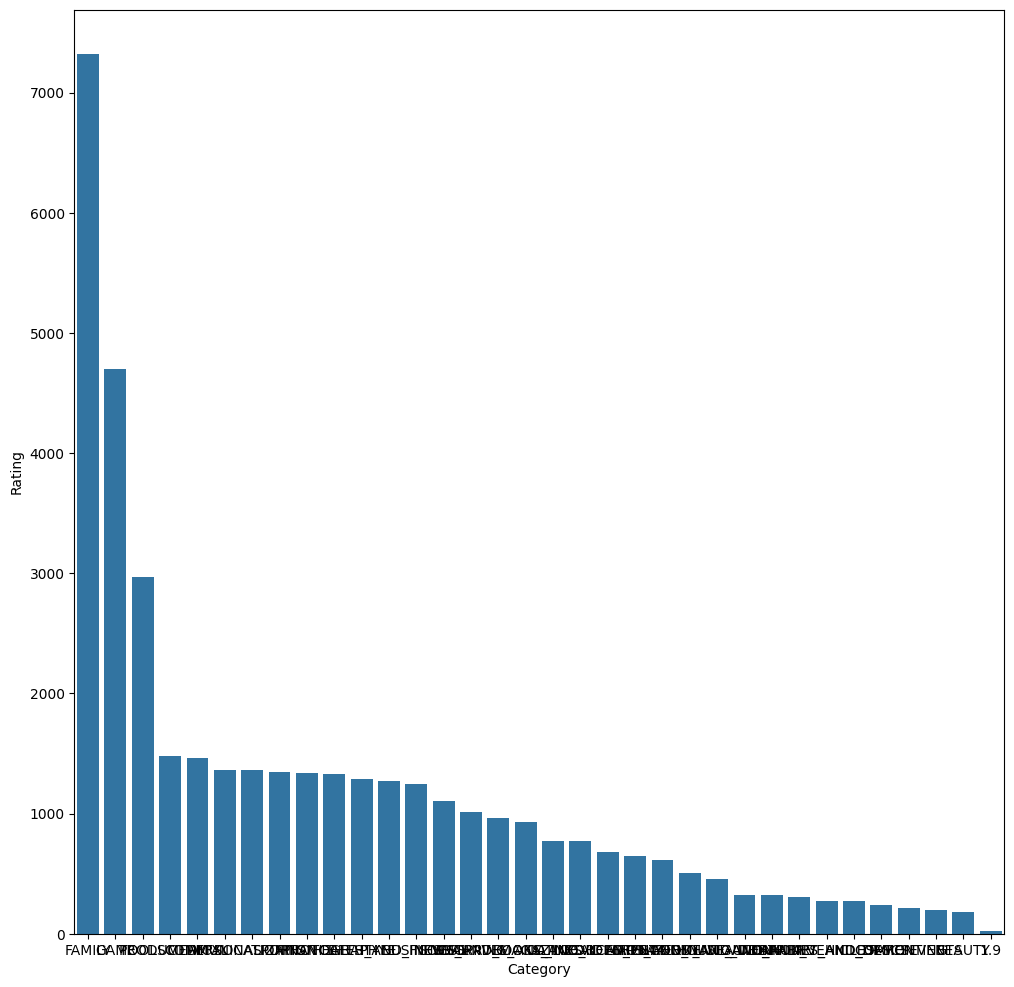

In [14]:
plt.figure(figsize=(12,12))
sns.barplot(x='Category',y='Rating',data=category_rating)

In [15]:
df['Type'].value_counts()

Type
Free    8719
Paid     647
0          1
Name: count, dtype: int64

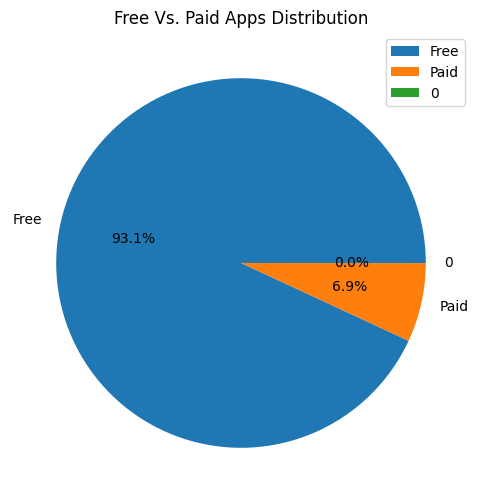

In [16]:
type_counts=df['Type'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(type_counts,labels=type_counts.index,autopct="%1.1f%%")
plt.title("Free Vs. Paid Apps Distribution")
plt.legend()
plt.show()

In [17]:
df['Installs']=df['Installs'].astype(str).str.replace('[+,]','',regex=True)
df['Installs']=pd.to_numeric(df['Installs'],errors='coerce')
df['Installs']=df['Installs'].fillna(0)
df['Installs']=df['Installs'].astype(int)

In [18]:
df['Installs'].dtypes

dtype('int64')

In [19]:
df['Installs'].sum()

np.int64(167627457938)

In [20]:
cat_installs=df.groupby('Category')['Installs'].sum().sort_values(ascending=False).reset_index()
print(cat_installs)

               Category     Installs
0                  GAME  35085862717
1         COMMUNICATION  32647241530
2          PRODUCTIVITY  14176070180
3                SOCIAL  14069841475
4                 TOOLS  11450724500
5                FAMILY  10257701590
6           PHOTOGRAPHY  10088243130
7    NEWS_AND_MAGAZINES   7496210650
8      TRAVEL_AND_LOCAL   6868859300
9         VIDEO_PLAYERS   6221897200
10             SHOPPING   3247831540
11        ENTERTAINMENT   2869160000
12      PERSONALIZATION   2325352930
13  BOOKS_AND_REFERENCE   1921291655
14               SPORTS   1751131465
15   HEALTH_AND_FITNESS   1583056220
16             BUSINESS   1001768120
17              FINANCE    876612400
18            EDUCATION    871352000
19  MAPS_AND_NAVIGATION    724267560
20            LIFESTYLE    537561120
21              WEATHER    426096500
22       FOOD_AND_DRINK    273777750
23               DATING    264295110
24       HOUSE_AND_HOME    168582000
25       ART_AND_DESIGN    124233100
2

Text(0.5, 1.0, 'Category Wise Installs')

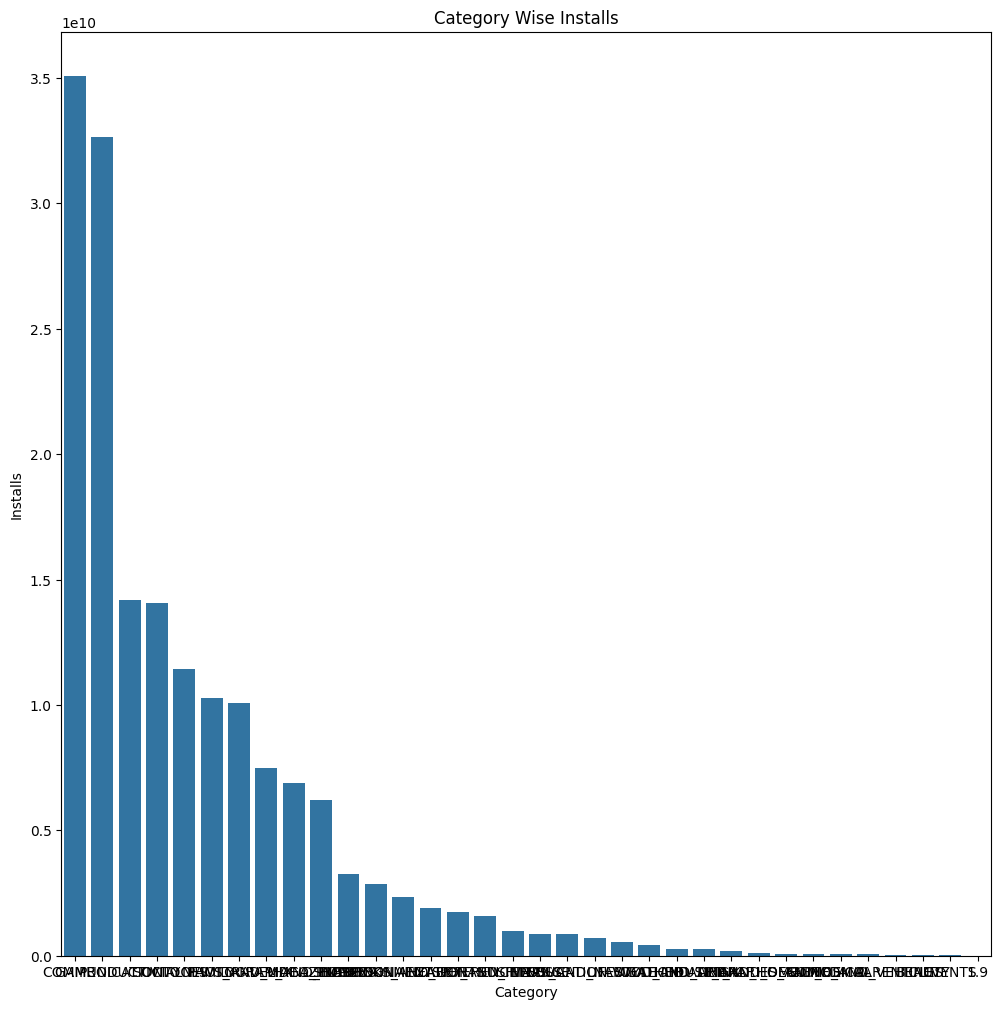

In [21]:
plt.figure(figsize=(12,12))
sns.barplot(x='Category',y='Installs',data=cat_installs)
plt.title("Category Wise Installs")

In [22]:
type_installs=df.groupby('Type')['Installs'].sum().reset_index()
print(type_installs)

   Type      Installs
0     0             0
1  Free  167554515356
2  Paid      72942582


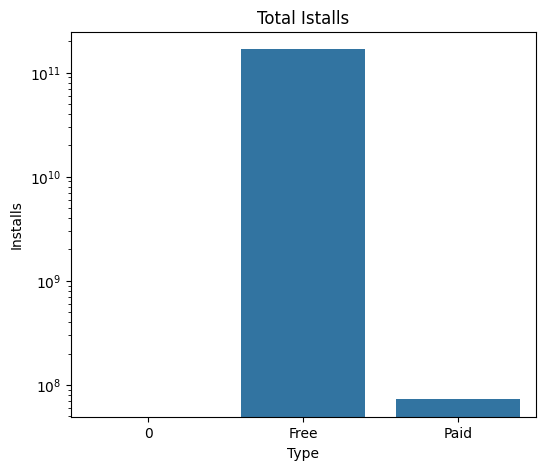

In [23]:
plt.figure(figsize=(6,5))
sns.barplot(data=type_installs,x='Type',y='Installs')
plt.yscale('log')
plt.title("Total Istalls")
plt.xlabel("Type")
plt.ylabel("Installs")
plt.show()

In [24]:
df['Price'].dtypes

<StringDtype(na_value=nan)>

In [25]:
df['Price']=df['Price'].str.replace('$','',regex=False)
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

In [26]:
df['Price'].dtypes

dtype('float64')

In [27]:
cat_price=df.groupby('Category')['Price'].sum().sort_values(ascending=False).reset_index()
print(cat_price)

               Category    Price
0               FINANCE  2439.87
1                FAMILY  2296.74
2             LIFESTYLE  1960.88
3               MEDICAL  1043.14
4                  GAME   280.36
5                 TOOLS   207.90
6       PERSONALIZATION   127.76
7                SPORTS    93.21
8           PHOTOGRAPHY    88.24
9              BUSINESS    74.39
10         PRODUCTIVITY    70.92
11        COMMUNICATION    56.69
12   HEALTH_AND_FITNESS    45.38
13     TRAVEL_AND_LOCAL    37.49
14              WEATHER    29.43
15  MAPS_AND_NAVIGATION    26.95
16  BOOKS_AND_REFERENCE    23.88
17               DATING    22.96
18            EDUCATION    17.96
19        VIDEO_PLAYERS    10.46
20            PARENTING     9.58
21       FOOD_AND_DRINK     8.48
22        ENTERTAINMENT     7.98
23       ART_AND_DESIGN     5.97
24             SHOPPING     5.48
25   NEWS_AND_MAGAZINES     3.98
26    AUTO_AND_VEHICLES     1.99
27               SOCIAL     1.98
28                  1.9     0.00
29        

Text(0.5, 1.0, 'All Category Prices')

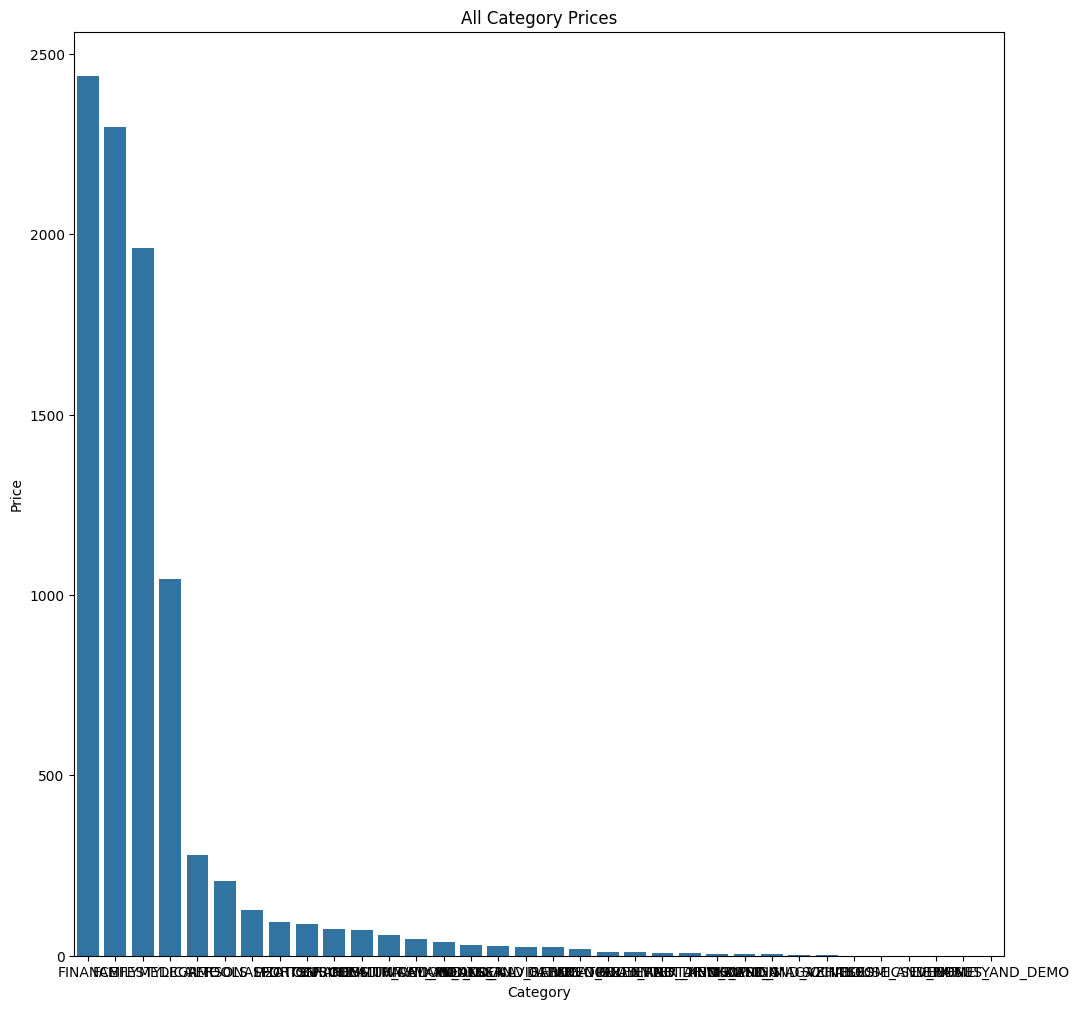

In [28]:
plt.figure(figsize=(12,12))
sns.barplot(x='Category',y='Price',data=cat_price)
plt.title("All Category Prices")

In [29]:
print("Family,Game and Tools are the top 3 highest rating categories")
print("Most of the people are preferring Free apps")
print("Game, Communication and Productivity are the top 3 highest installs")
print("Most of the people are installing Free type of app")
print("Finance, Family, Lifestyle and Medical are the top 4 highest price categories")

Family,Game and Tools are the top 3 highest rating categories
Most of the people are preferring Free apps
Game, Communication and Productivity are the top 3 highest installs
Most of the people are installing Free type of app
Finance, Family, Lifestyle and Medical are the top 4 highest price categories
